In [1]:
import numpy as np
import pandas as pd
import hdbscan
import math
import matplotlib.pyplot as plt

from tslearn.barycenters import dtw_barycenter_averaging

In [2]:
target_mmsi = 311014800

D_noise = np.load("D_triuksmai_80_dtw_float32.npy", mmap_mode="r")
noise_meta = pd.read_csv("triuksmai_metadata_80.csv")

print("D_noise shape:", D_noise.shape)
print("D_noise dtype:", D_noise.dtype)
print("noise_meta shape:", noise_meta.shape)

if D_noise.shape[0] != len(noise_meta):
    raise ValueError("D_noise ir noise_meta ilgiai nesutampa.")

print("Min distance:", np.nanmin(D_noise))
print("Max distance:", np.nanmax(D_noise))
print("Ar yra NaN:", np.isnan(D_noise).any())
print("Ar yra inf:", np.isinf(D_noise).any())

target_rows = noise_meta.index[
    noise_meta["mmsi"].astype(str) == str(target_mmsi)
].to_numpy()

print("\nTarget MMSI:", target_mmsi)
print("Target rows triukšmų masyve:", target_rows)

if len(target_rows) > 0:
    display(noise_meta.iloc[target_rows])
else:
    print("Target MMSI nerastas šiame 80 % triukšmų rinkinyje.")

D_noise shape: (2777, 2777)
D_noise dtype: float32
noise_meta shape: (2777, 18)
Min distance: 0.0
Max distance: 296.00732
Ar yra NaN: False
Ar yra inf: False

Target MMSI: 311014800
Target rows triukšmų masyve: [1567]


,noise_row,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,source,source_row,global_idx,hdbscan_cluster
1567,1567,40469,311014800,1,2025-05-17 07:56:00,2025-05-17 09:34:00,0,49,-0.015799,-0.004248,13.0,13.0,13_13,True,sample,4009,40469,-1


In [3]:
D_noise_hdb = np.asarray(D_noise, dtype=np.float64)
D_noise_hdb = np.ascontiguousarray(D_noise_hdb)

np.fill_diagonal(D_noise_hdb, 0.0)

print("D_noise_hdb dtype:", D_noise_hdb.dtype)
print("D_noise_hdb shape:", D_noise_hdb.shape)
print("Ar yra NaN:", np.isnan(D_noise_hdb).any())
print("Ar yra inf:", np.isinf(D_noise_hdb).any())

D_noise_hdb dtype: float64
D_noise_hdb shape: (2777, 2777)
Ar yra NaN: False
Ar yra inf: False


In [4]:
param_results = []

min_cluster_sizes = [5, 10, 15, 20, 30, 50, 75, 100]
min_samples_values = [1, 2, 3, 5, 10, 15, 20]
methods = ["eom", "leaf"]

if len(target_rows) > 0:
    target_row = target_rows[0]
else:
    target_row = None

for method in methods:
    for min_cluster_size in min_cluster_sizes:
        for min_samples in min_samples_values:

            if min_samples > min_cluster_size:
                continue

            clusterer = hdbscan.HDBSCAN(
                metric="precomputed",
                min_cluster_size=min_cluster_size,
                min_samples=min_samples,
                cluster_selection_method=method
            )

            labels = clusterer.fit_predict(D_noise_hdb)

            n = len(labels)
            n_subclusters = len(set(labels)) - (1 if -1 in labels else 0)

            n_noise = np.sum(labels == -1)
            noise_percent = n_noise / n * 100

            sizes = pd.Series(labels).value_counts().sort_index()
            non_noise_sizes = sizes[sizes.index != -1]

            if len(non_noise_sizes) > 0:
                largest_subcluster_size = non_noise_sizes.max()
                largest_subcluster_percent = largest_subcluster_size / n * 100
                smallest_subcluster_size = non_noise_sizes.min()
                median_subcluster_size = non_noise_sizes.median()
            else:
                largest_subcluster_size = 0
                largest_subcluster_percent = 0
                smallest_subcluster_size = 0
                median_subcluster_size = 0

            subcluster_sizes_text = ", ".join(
                [f"{cluster}: {size}" for cluster, size in non_noise_sizes.sort_values(ascending=False).items()]
            )

            all_cluster_sizes_text = ", ".join(
                [f"{cluster}: {size}" for cluster, size in sizes.sort_values(ascending=False).items()]
            )

            if target_row is not None:
                target_subcluster = labels[target_row]

                if target_subcluster == -1:
                    target_subcluster_size = 0
                else:
                    target_subcluster_size = np.sum(labels == target_subcluster)

                target_is_noise = target_subcluster == -1
            else:
                target_subcluster = None
                target_subcluster_size = None
                target_is_noise = None

            param_results.append({
                "method": method,
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "n_subclusters": n_subclusters,
                "noise_sequences": n_noise,
                "noise_percent": round(noise_percent, 2),
                "largest_subcluster_size": largest_subcluster_size,
                "largest_subcluster_percent": round(largest_subcluster_percent, 2),
                "median_subcluster_size": median_subcluster_size,
                "smallest_subcluster_size": smallest_subcluster_size,
                "subcluster_sizes": subcluster_sizes_text,
                "all_cluster_sizes": all_cluster_sizes_text,
                "target_subcluster": target_subcluster,
                "target_subcluster_size": target_subcluster_size,
                "target_is_noise": target_is_noise
            })

param_results_df = pd.DataFrame(param_results)

pd.set_option("display.max_colwidth", 500)

display(param_results_df)

,method,min_cluster_size,min_samples,n_subclusters,noise_sequences,noise_percent,largest_subcluster_size,largest_subcluster_percent,median_subcluster_size,smallest_subcluster_size,subcluster_sizes,all_cluster_sizes,target_subcluster,target_subcluster_size,target_is_noise
0,eom,5,1,85,1980,71.30,35,1.26,6.0,5,"24: 35, 61: 27, 73: 27, 44: 24, 53: 23, 58: 22, 74: 22, 50: 19, 76: 19, 79: 18, 19: 18, 81: 16, 77: 16, 18: 15, 30: 13, 40: 13, 32: 13, 59: 12, 16: 12, 0: 12, 17: 11, 83: 11, 72: 11, 23: 11, 57: 11, 52: 10, 31: 10, 67: 9, 28: 9, 43: 9, 56: 8, 33: 8, 37: 8, 29: 8, 27: 8, 15: 7, 7: 7, 66: 7, 55: 7, 26: 7, 35: 7, 45: 7, 65: 6, 64: 6, 80: 6, 71: 6, 49: 6, 14: 6, 20: 6, 5: 6, 6: 6, 84: 6, 78: 6, 39: 6, 68: 6, 60: 6, 34: 6, 13: 5, 10: 5, 3: 5, 4: 5, 1: 5, 2: 5, 11: 5, 8: 5, 9: 5, 12: 5, 22: 5, 21:...","-1: 1980, 24: 35, 61: 27, 73: 27, 44: 24, 53: 23, 58: 22, 74: 22, 50: 19, 76: 19, 79: 18, 19: 18, 81: 16, 77: 16, 18: 15, 30: 13, 40: 13, 32: 13, 59: 12, 16: 12, 0: 12, 17: 11, 83: 11, 72: 11, 23: 11, 57: 11, 52: 10, 31: 10, 67: 9, 28: 9, 43: 9, 56: 8, 33: 8, 37: 8, 29: 8, 27: 8, 15: 7, 7: 7, 66: 7, 55: 7, 26: 7, 35: 7, 45: 7, 65: 6, 64: 6, 80: 6, 71: 6, 49: 6, 14: 6, 20: 6, 5: 6, 6: 6, 84: 6, 78: 6, 39: 6, 68: 6, 60: 6, 34: 6, 13: 5, 10: 5, 3: 5, 4: 5, 1: 5, 2: 5, 11: 5, 8: 5, 9: 5, 12: 5, ...",-1,0,True
1,eom,5,2,2,33,1.19,2736,98.52,1372.0,8,"0: 2736, 1: 8","0: 2736, -1: 33, 1: 8",0,2736,False
2,eom,5,3,2,34,1.22,2736,98.52,1371.5,7,"0: 2736, 1: 7","0: 2736, -1: 34, 1: 7",0,2736,False
3,eom,5,5,22,2290,82.46,77,2.77,16.5,5,"11: 77, 12: 57, 5: 51, 10: 32, 7: 30, 8: 26, 14: 22, 13: 22, 20: 18, 16: 18, 18: 17, 21: 16, 17: 15, 1: 13, 6: 13, 9: 12, 15: 10, 4: 9, 3: 8, 2: 8, 19: 8, 0: 5","-1: 2290, 11: 77, 12: 57, 5: 51, 10: 32, 7: 30, 8: 26, 14: 22, 13: 22, 20: 18, 16: 18, 18: 17, 21: 16, 17: 15, 1: 13, 6: 13, 9: 12, 15: 10, 4: 9, 3: 8, 2: 8, 19: 8, 0: 5",-1,0,True
4,eom,10,1,2,29,1.04,2736,98.52,1374.0,12,"0: 2736, 1: 12","0: 2736, -1: 29, 1: 12",0,2736,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,leaf,100,3,2,1214,43.72,819,29.49,781.5,744,"0: 819, 1: 744","-1: 1214, 0: 819, 1: 744",0,819,False
96,leaf,100,5,2,1162,41.84,982,35.36,807.5,633,"0: 982, 1: 633","-1: 1162, 0: 982, 1: 633",0,982,False
97,leaf,100,10,2,1127,40.58,1007,36.26,825.0,643,"0: 1007, 1: 643","-1: 1127, 0: 1007, 1: 643",0,1007,False
98,leaf,100,15,2,1035,37.27,1100,39.61,871.0,642,"0: 1100, 1: 642","0: 1100, -1: 1035, 1: 642",0,1100,False


In [5]:
candidate_results = param_results_df[
    (param_results_df["n_subclusters"] >= 2) &
    (param_results_df["noise_percent"] < 60) &
    (param_results_df["largest_subcluster_percent"] < 70)
].copy()

cols_to_show = [
    "method",
    "min_cluster_size",
    "min_samples",
    "n_subclusters",
    "noise_percent",
    "noise_sequences",
    "largest_subcluster_percent",
    "subcluster_sizes",
    "target_subcluster",
    "target_subcluster_size",
    "target_is_noise"
]

display(
    candidate_results[cols_to_show]
    .sort_values(
        by=["target_is_noise", "n_subclusters", "noise_percent"],
        ascending=[True, False, True]
    )
)

,method,min_cluster_size,min_samples,n_subclusters,noise_percent,noise_sequences,largest_subcluster_percent,subcluster_sizes,target_subcluster,target_subcluster_size,target_is_noise
15,eom,20,1,10,54.70,1519,29.06,"3: 807, 1: 110, 7: 78, 8: 68, 5: 62, 4: 35, 6: 32, 9: 23, 2: 22, 0: 21",3,807,False
16,eom,20,2,9,58.91,1636,26.79,"2: 744, 0: 91, 6: 76, 7: 64, 4: 59, 3: 33, 5: 31, 8: 23, 1: 20",2,744,False
80,leaf,50,2,5,56.86,1579,31.33,"0: 870, 3: 102, 1: 91, 4: 76, 2: 59",0,870,False
81,leaf,50,3,5,59.42,1650,29.49,"0: 819, 3: 97, 1: 82, 4: 74, 2: 55",0,819,False
8,eom,10,10,4,44.87,1246,29.71,"2: 825, 1: 643, 3: 45, 0: 18",2,825,False
13,eom,15,10,4,44.87,1246,29.71,"2: 825, 1: 643, 3: 45, 0: 18",2,825,False
84,leaf,50,15,4,52.11,1447,39.61,"0: 1100, 2: 103, 3: 75, 1: 52",0,1100,False
85,leaf,50,20,4,54.27,1507,37.20,"0: 1033, 2: 104, 3: 80, 1: 53",0,1033,False
86,leaf,75,1,4,55.20,1533,34.14,"0: 948, 1: 110, 2: 108, 3: 78",0,948,False
87,leaf,75,2,4,58.98,1638,31.33,"0: 870, 2: 102, 1: 91, 3: 76",0,870,False


In [6]:
min_cluster_size = 10
min_samples = 10
cluster_selection_method = "eom"

clusterer_noise_80_20_5 = hdbscan.HDBSCAN(
    metric="precomputed",
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    cluster_selection_method=cluster_selection_method
)

labels_noise_80_20_5 = clusterer_noise_80_20_5.fit_predict(D_noise_hdb)

noise_meta_80_20_5 = noise_meta.copy()
noise_meta_80_20_5["noise_subcluster"] = labels_noise_80_20_5
noise_meta_80_20_5["subcluster_probability"] = clusterer_noise_80_20_5.probabilities_

print("Baigta.")
print("Unikalūs subklasteriai:", sorted(noise_meta_80_20_5["noise_subcluster"].unique()))
print("Subklasterių kiekis be triukšmo:", len(set(labels_noise_80_20_5)) - (1 if -1 in labels_noise_80_20_5 else 0))
print("Likęs triukšmas:", np.sum(labels_noise_80_20_5 == -1))
print("Likęs triukšmas, %:", round(np.mean(labels_noise_80_20_5 == -1) * 100, 2))

Baigta.
Unikalūs subklasteriai: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Subklasterių kiekis be triukšmo: 4
Likęs triukšmas: 1246
Likęs triukšmas, %: 44.87


In [7]:
subcluster_summary_80_20_5 = (
    noise_meta_80_20_5["noise_subcluster"]
    .value_counts()
    .reset_index()
)

subcluster_summary_80_20_5.columns = ["noise_subcluster", "n_sequences"]

subcluster_summary_80_20_5["percent"] = (
    subcluster_summary_80_20_5["n_sequences"] / len(noise_meta_80_20_5) * 100
).round(2)

subcluster_summary_80_20_5 = (
    subcluster_summary_80_20_5
    .sort_values("noise_subcluster")
    .reset_index(drop=True)
)

display(subcluster_summary_80_20_5)

,noise_subcluster,n_sequences,percent
0,-1,1246,44.87
1,0,18,0.65
2,1,643,23.15
3,2,825,29.71
4,3,45,1.62


In [8]:
target_rows_80_20_5 = noise_meta_80_20_5[
    noise_meta_80_20_5["mmsi"].astype(str) == str(target_mmsi)
].copy()

display(target_rows_80_20_5)

if len(target_rows_80_20_5) > 0:
    target_subcluster = target_rows_80_20_5["noise_subcluster"].iloc[0]
    target_subcluster_size = (
        noise_meta_80_20_5["noise_subcluster"] == target_subcluster
    ).sum()

    print("Target MMSI:", target_mmsi)
    print("Target noise_subcluster:", target_subcluster)
    print("Target subcluster dydis:", target_subcluster_size)
else:
    print("Tiriamas MMSI nerastas 80 % triukšmo metadata faile.")

,noise_row,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,source,source_row,global_idx,hdbscan_cluster,noise_subcluster,subcluster_probability
1567,1567,40469,311014800,1,2025-05-17 07:56:00,2025-05-17 09:34:00,0,49,-0.015799,-0.004248,13.0,13.0,13_13,True,sample,4009,40469,-1,2,0.576739


Target MMSI: 311014800
Target noise_subcluster: 2
Target subcluster dydis: 825


In [11]:
np.save(
    "triuksmai_80_hdbscan_20_5_labels.npy",
    labels_noise_80_20_5
)

noise_meta_80_20_5.to_csv(
    "triuksmai_80_metadata_hdbscan_20_5.csv",
    index=False
)

subcluster_summary_80_20_5.to_csv(
    "triuksmai_80_hdbscan_20_5_summary.csv",
    index=False
)

print("Išsaugota:")
print("triuksmai_80_hdbscan_20_5_labels.npy")
print("triuksmai_80_metadata_hdbscan_20_5.csv")
print("triuksmai_80_hdbscan_20_5_summary.csv")

Išsaugota:
triuksmai_80_hdbscan_20_5_labels.npy
triuksmai_80_metadata_hdbscan_20_5.csv
triuksmai_80_hdbscan_20_5_summary.csv


Triukšmo trajektorijų: 2777
Labelių kiekis: 2777


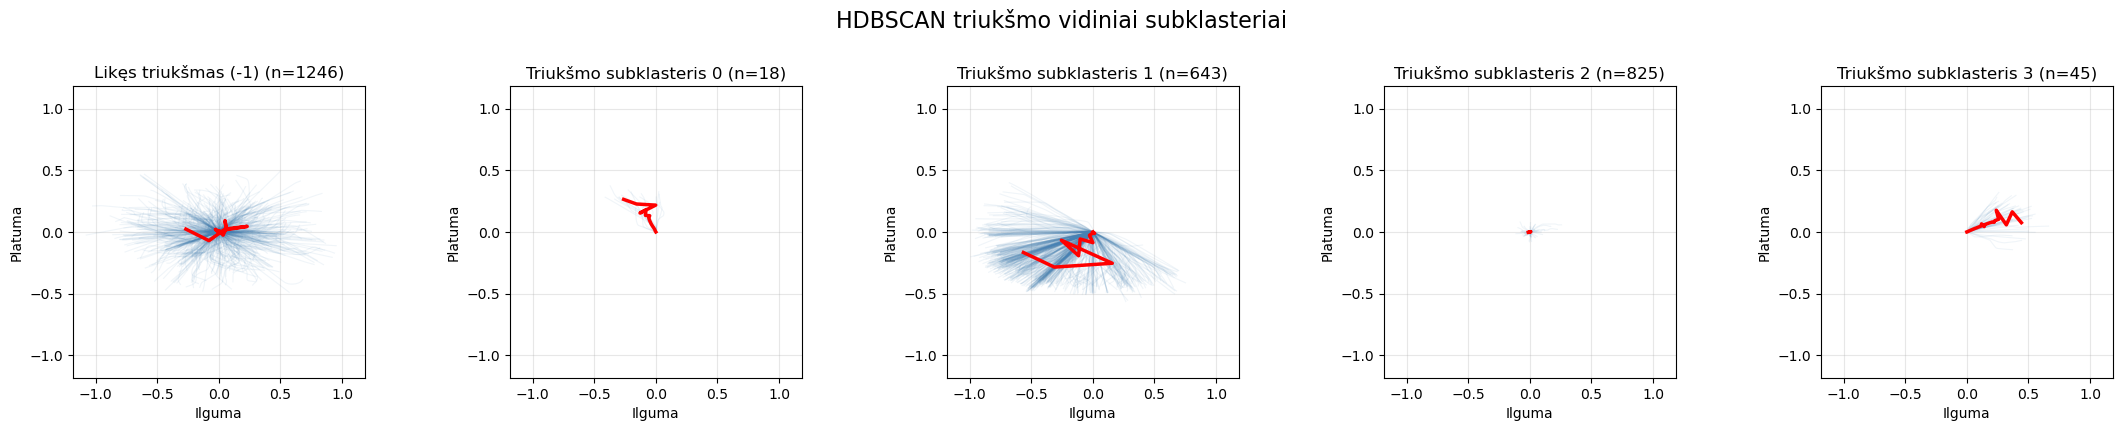

In [12]:
X_raw = np.load("X_w50_raw.npy", allow_pickle=False)

noise_global_idx = noise_meta_80_20_5["global_idx"].to_numpy()

X = X_raw[noise_global_idx].astype(np.float64)
labels = noise_meta_80_20_5["noise_subcluster"].to_numpy()

if len(X) != len(labels):
    raise ValueError("KLAIDA: X ir labels ilgiai nesutampa.")

print("Triukšmo trajektorijų:", len(X))
print("Labelių kiekis:", len(labels))

all_y_global = X[:, :, 0].ravel()
all_x_global = X[:, :, 1].ravel()

valid_global = np.isfinite(all_x_global) & np.isfinite(all_y_global)

all_x_global = all_x_global[valid_global]
all_y_global = all_y_global[valid_global]

xmin, xmax = np.min(all_x_global), np.max(all_x_global)
ymin, ymax = np.min(all_y_global), np.max(all_y_global)

max_abs = max(abs(xmin), abs(xmax), abs(ymin), abs(ymax))
pad = max(max_abs * 0.1, 0.001)

xlim_global = (-max_abs - pad, max_abs + pad)
ylim_global = (-max_abs - pad, max_abs + pad)

unique_clusters = sorted(np.unique(labels))

n_clusters = len(unique_clusters)
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, 4.2 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)

rng = np.random.default_rng(42)

for plot_i, k in enumerate(unique_clusters):
    ax = axes[plot_i]

    idx = np.where(labels == k)[0]

    for i in idx:
        coords = X[i]

        y = coords[:, 0]
        x = coords[:, 1]

        valid = np.isfinite(x) & np.isfinite(y)

        if valid.any():
            ax.plot(
                x[valid],
                y[valid],
                color="steelblue",
                alpha=0.08,
                linewidth=0.8
            )

    if len(idx) > 0:
        if len(idx) > 200:
            idx_for_bary = rng.choice(idx, size=200, replace=False)
        else:
            idx_for_bary = idx

        cluster_series = X[idx_for_bary, :, :2]

        barycenter = dtw_barycenter_averaging(
            cluster_series,
            max_iter=20
        )

        valid_bary = (
            np.isfinite(barycenter[:, 0])
            & np.isfinite(barycenter[:, 1])
        )

        ax.plot(
            barycenter[valid_bary, 1],
            barycenter[valid_bary, 0],
            color="red",
            linewidth=2.5
        )

    ax.set_xlim(xlim_global)
    ax.set_ylim(ylim_global)

    title_name = "Likęs triukšmas (-1)" if k == -1 else f"Triukšmo subklasteris {k}"
    ax.set_title(f"{title_name} (n={len(idx)})")

    ax.set_xlabel("Ilguma")
    ax.set_ylabel("Platuma")

    ax.tick_params(
        axis="both",
        which="both",
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True
    )

    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "HDBSCAN triukšmo vidiniai subklasteriai",
    fontsize=16,
    x=0.5,
    ha="center"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [10]:
target_subcluster = 2

cluster_meta = noise_meta_80_20_5[
    noise_meta_80_20_5["noise_subcluster"] == target_subcluster
].copy()

print("Subklasteris:", target_subcluster)
print("Sekų kiekis:", len(cluster_meta))
print("Unikalių MMSI:", cluster_meta["mmsi"].nunique())

print("\nTop 20 MMSI pagal sekų kiekį šiame subklasteryje:")
display(
    cluster_meta["mmsi"]
    .value_counts()
    .head(20)
    .reset_index()
    .rename(columns={"index": "mmsi", "mmsi": "n_sequences"})
)

print("\nTiriamo laivo seka šiame subklasteryje:")
display(
    cluster_meta[
        cluster_meta["mmsi"].astype(str) == str(target_mmsi)
    ]
)

Subklasteris: 2
Sekų kiekis: 825
Unikalių MMSI: 293

Top 20 MMSI pagal sekų kiekį šiame subklasteryje:


,n_sequences,count
0,219000805,20
1,219024284,18
2,219003217,16
3,231815000,14
4,219616000,11
5,219671000,11
6,255739000,11
7,209325000,11
8,210051000,10
9,574005070,10



Tiriamo laivo seka šiame subklasteryje:


,noise_row,sequence_id,mmsi,block_id,start_time,end_time,window_start_idx,window_end_idx,center_x,center_y,x_bin,y_bin,stratum,is_forced_vessel,source,source_row,global_idx,hdbscan_cluster,noise_subcluster,subcluster_probability
1567,1567,40469,311014800,1,2025-05-17 07:56:00,2025-05-17 09:34:00,0,49,-0.015799,-0.004248,13.0,13.0,13_13,True,sample,4009,40469,-1,2,0.576739
